In [112]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

In [69]:
dataset = pd.read_csv('Spam Filtering Data.csv')
dataset

,Unnamed: 0,Body,Label
0,0,\nSave up to 70% on Life Insurance.\nWhy Spend...,1
1,1,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
2,2,1) Fight The Risk of Cancer!\nhttp://www.adcli...,1
3,3,##############################################...,1
4,4,I thought you might like these:\n1) Slim Down ...,1
...,...,...,...
6041,6041,empty,0
6042,6042,___ ___ ...,0
6043,6043,IN THIS ISSUE:01. Readers write\n02. Extension...,0
6044,6044,empty,0


In [77]:
dataset.columns

Index(['Unnamed: 0', 'Body', 'Label'], dtype='object')

In [78]:
dataset.isnull().sum()

Unnamed: 0    0
Body          0
Label         0
dtype: int64

In [79]:
dataset[dataset.isnull().any(axis=1)]

,Unnamed: 0,Body,Label


In [80]:
dataset = dataset.dropna()

In [81]:
dataset.isnull().sum()

Unnamed: 0    0
Body          0
Label         0
dtype: int64

In [82]:
dataset['Body'] = dataset['Body'].astype(str)

In [83]:
import re

In [84]:
def clean_text(text):
    text = re.sub('\s+', ' ', text).strip()
    text = text.replace('\n', ' ').strip()
    return text

In [85]:
dataset['Body'] = dataset['Body'].apply(clean_text)

In [86]:
dataset

,Unnamed: 0,Body,Label
0,0,Save up to 70% on Life Insurance. Why Spend Mo...,1
1,1,1) Fight The Risk of Cancer! http://www.adclic...,1
2,2,1) Fight The Risk of Cancer! http://www.adclic...,1
3,3,##############################################...,1
4,4,I thought you might like these: 1) Slim Down -...,1
...,...,...,...
6041,6041,empty,0
6042,6042,___ ___ ___ /\ \ /\ \ /\ \ ___ |::\ \ \:\ \ /:...,0
6043,6043,IN THIS ISSUE:01. Readers write 02. Extension ...,0
6044,6044,empty,0


In [87]:
from nltk import word_tokenize
from nltk.corpus import stopwords

In [88]:
def preprocess_text(text):
    tokens = word_tokenize(text)
    
    stop_words = set(stopwords.words('english'))
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words]
    
    return filtered_tokens

In [89]:
dataset['Body'] = dataset['Body'].apply(preprocess_text)

In [90]:
dataset

,Unnamed: 0,Body,Label
0,0,"[Save, 70, %, Life, Insurance, ., Spend, ?, Li...",1
1,1,"[1, ), Fight, Risk, Cancer, !, http, :, //www....",1
2,2,"[1, ), Fight, Risk, Cancer, !, http, :, //www....",1
3,3,"[#, #, #, #, #, #, #, #, #, #, #, #, #, #, #, ...",1
4,4,"[thought, might, like, :, 1, ), Slim, -, Guara...",1
...,...,...,...
6041,6041,[empty],0
6042,6042,"[___, ___, ___, /\, \, /\, \, /\, \, ___, |, :...",0
6043,6043,"[ISSUE:01, ., Readers, write, 02, ., Extension...",0
6044,6044,[empty],0


In [95]:
X = dataset['Body'] 
y = dataset['Label']  

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
X_train = [' '.join(doc) for doc in X_train]
X_test = [' '.join(doc) for doc in X_test]

In [96]:
y_train.head(50)

184     1
4924    0
2914    0
2459    0
534     1
3140    0
2719    0
2133    0
3215    0
658     1
1256    1
3247    0
3128    0
2518    0
3461    0
899     1
429     1
4163    0
2046    0
4726    0
1437    1
5469    0
1223    1
2100    0
1877    1
3075    0
1700    1
5003    0
3425    0
2888    0
2264    0
2489    0
2526    0
2601    0
1868    1
5458    0
2716    0
4990    0
2935    0
2755    0
4956    0
1411    1
4373    0
5628    0
5742    0
192     1
5823    0
1127    1
1861    1
3436    0
Name: Label, dtype: int64

In [99]:
# Loop over each size of attributes to find the best size of attributes:
from sklearn.metrics import accuracy_score
attribute_sizes = [500, 1000, 3000, 4000, 5000, 6000]
for size in attribute_sizes:
    
    vectorizer = CountVectorizer(max_features=size)
    X_train_vec = vectorizer.fit_transform(X_train)
    X_test_vec = vectorizer.transform(X_test)

    nb_classifier = MultinomialNB()
    nb_classifier.fit(X_train_vec, y_train)

    y_pred = nb_classifier.predict(X_test_vec)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'accuracy for size = {size}:', accuracy)

accuracy for size = 500: 0.9246031746031746
accuracy for size = 1000: 0.9298941798941799
accuracy for size = 3000: 0.9384920634920635
accuracy for size = 4000: 0.9411375661375662
accuracy for size = 5000: 0.9424603174603174
accuracy for size = 6000: 0.9457671957671958


#### After 4000 there is no significant increase in accuracy. So, we select the size at 4000.

In [100]:
vectorizer = CountVectorizer(max_features=4000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

In [122]:
from sklearn.naive_bayes import GaussianNB, BernoulliNB 
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.metrics import roc_curve, auc

In [197]:
metrics = {'Classifier': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1 Score': [], 'ROC curve area': []}

### MultinomialNB:

Accuracy: 0.9411375661375662
Confusion Matrix:
 [[949  59]
 [ 30 474]]
Precision: 0.8893058161350844
Recall: 0.9404761904761905
F1 Score: 0.914175506268081


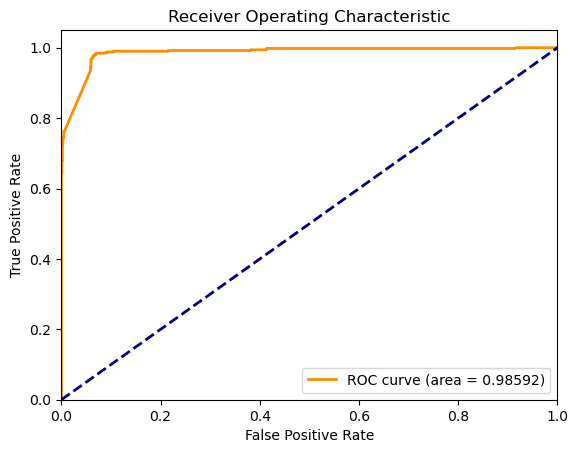

In [198]:
mnb_classifier = MultinomialNB()
mnb_classifier.fit(X_train_vec, y_train)
        
y_pred = mnb_classifier.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary') 
recall = recall_score(y_test, y_pred, average='binary') 
f1 = f1_score(y_test, y_pred, average='binary')

print('Accuracy:', accuracy)
print('Confusion Matrix:\n', conf_matrix)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

y_pred_prob = mnb_classifier.predict_proba(X_test_vec)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

new_record = {'Classifier': 'MultinomialNB', 'Accuracy': accuracy, 'Precision': precision, 
              'Recall': recall, 'F1 Score': f1, 'ROC curve area': roc_auc}

for key, value in new_record.items():
    metrics[key].append(value)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.5f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [185]:
metrics

{'Classifier': ['MultinomialNB'],
 'Accuracy': [0.9411375661375662],
 'Precision': [0.8893058161350844],
 'Recall': [0.9404761904761905],
 'F1 Score': [0.914175506268081],
 'ROC curve area': [0.98592116244646]}

### GaussianNB:

Accuracy: 0.908068783068783
Confusion Matrix:
 [[898 110]
 [ 29 475]]
Precision: 0.811965811965812
Recall: 0.9424603174603174
F1 Score: 0.8723599632690541


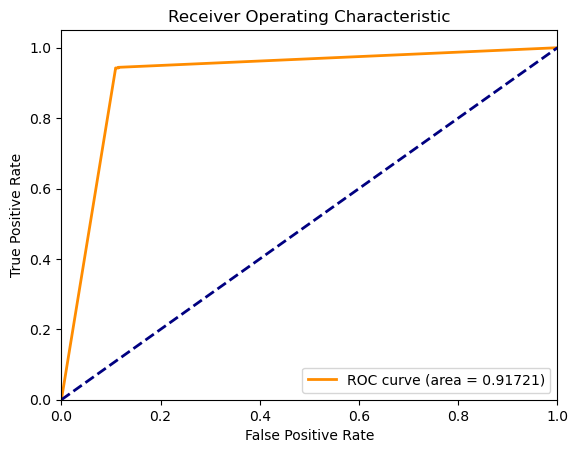

In [199]:
# Convert sparse matrix to dense to be prepared for GaussianNB classifier:
X_train_vec_dense = X_train_vec.toarray()
X_test_vec_dense = X_test_vec.toarray()
        
gnb_classifier = GaussianNB()
gnb_classifier.fit(X_train_vec_dense, y_train)
        
y_pred = gnb_classifier.predict(X_test_vec_dense)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary') 
recall = recall_score(y_test, y_pred, average='binary') 
f1 = f1_score(y_test, y_pred, average='binary')

print('Accuracy:', accuracy)
print('Confusion Matrix:\n', conf_matrix)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

y_pred_prob = gnb_classifier.predict_proba(X_test_vec_dense)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

new_record = {'Classifier': 'GaussianNB', 'Accuracy': accuracy, 'Precision': precision, 
              'Recall': recall, 'F1 Score': f1, 'ROC curve area': roc_auc}

for key, value in new_record.items():
    metrics[key].append(value)
    
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.5f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### BernoulliNB:

Accuracy: 0.9484126984126984
Confusion Matrix:
 [[944  64]
 [ 14 490]]
Precision: 0.8844765342960289
Recall: 0.9722222222222222
F1 Score: 0.9262759924385633


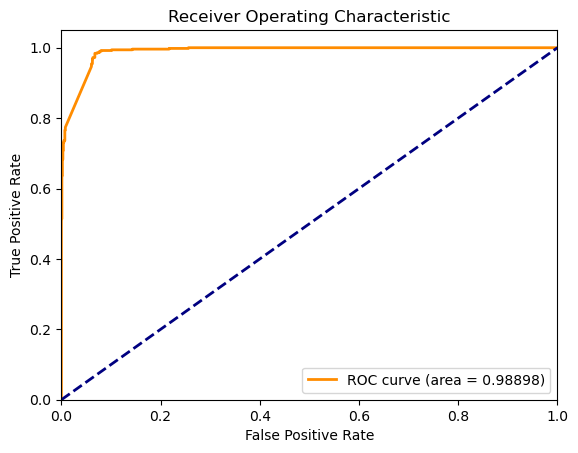

In [200]:
bnb_classifier = BernoulliNB()
bnb_classifier.fit(X_train_vec, y_train)
        
y_pred = bnb_classifier.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary') 
recall = recall_score(y_test, y_pred, average='binary') 
f1 = f1_score(y_test, y_pred, average='binary')

print('Accuracy:', accuracy)
print('Confusion Matrix:\n', conf_matrix)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

y_pred_prob = bnb_classifier.predict_proba(X_test_vec)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

new_record = {'Classifier': 'BernoulliNB', 'Accuracy': accuracy, 'Precision': precision, 
              'Recall': recall, 'F1 Score': f1, 'ROC curve area': roc_auc}

for key, value in new_record.items():
    metrics[key].append(value)
    
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.5f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### Support Vector Machines (SVM):

Accuracy: 0.9431216931216931
Confusion Matrix:
 [[943  65]
 [ 21 483]]
Precision: 0.8813868613138686
Recall: 0.9583333333333334
F1 Score: 0.9182509505703422


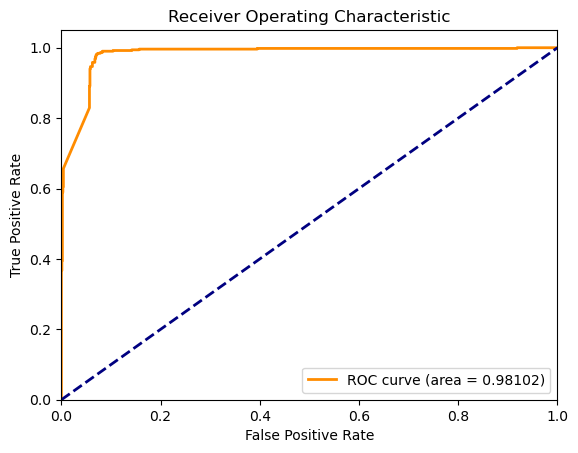

In [201]:
svm_classifier = SVC(kernel='linear', probability=True)
svm_classifier.fit(X_train_vec, y_train)
        
y_pred = svm_classifier.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary') 
recall = recall_score(y_test, y_pred, average='binary') 
f1 = f1_score(y_test, y_pred, average='binary')

print('Accuracy:', accuracy)
print('Confusion Matrix:\n', conf_matrix)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

y_pred_prob = svm_classifier.predict_proba(X_test_vec)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

new_record = {'Classifier': 'Support Vector Machines (SVM)', 'Accuracy': accuracy, 'Precision': precision, 
              'Recall': recall, 'F1 Score': f1, 'ROC curve area': roc_auc}

for key, value in new_record.items():
    metrics[key].append(value)
    
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.5f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### Logistic Regression:

Accuracy: 0.9477513227513228
Confusion Matrix:
 [[950  58]
 [ 21 483]]
Precision: 0.8927911275415896
Recall: 0.9583333333333334
F1 Score: 0.924401913875598


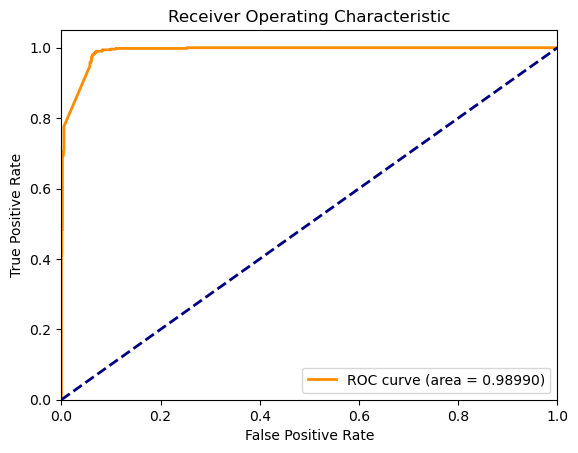

In [202]:
log_classifier = LogisticRegression()
log_classifier.fit(X_train_vec, y_train)
        
y_pred = log_classifier.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary') 
recall = recall_score(y_test, y_pred, average='binary') 
f1 = f1_score(y_test, y_pred, average='binary')

print('Accuracy:', accuracy)
print('Confusion Matrix:\n', conf_matrix)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

y_pred_prob = log_classifier.predict_proba(X_test_vec)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

new_record = {'Classifier': 'Logistic Regression', 'Accuracy': accuracy, 'Precision': precision, 
              'Recall': recall, 'F1 Score': f1, 'ROC curve area': roc_auc}

for key, value in new_record.items():
    metrics[key].append(value)
    
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.5f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### Gradient Boosting Machines (GBM):

Accuracy: 0.9259259259259259
Confusion Matrix:
 [[944  64]
 [ 48 456]]
Precision: 0.8769230769230769
Recall: 0.9047619047619048
F1 Score: 0.890625


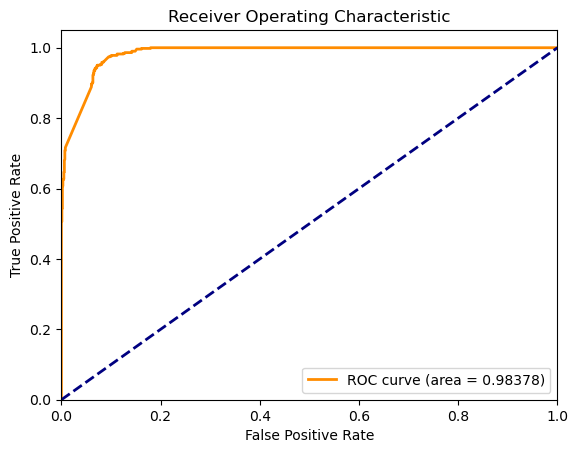

In [203]:
gbm_classifier = GradientBoostingClassifier()
gbm_classifier.fit(X_train_vec, y_train)
        
y_pred = gbm_classifier.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary') 
recall = recall_score(y_test, y_pred, average='binary') 
f1 = f1_score(y_test, y_pred, average='binary')

print('Accuracy:', accuracy)
print('Confusion Matrix:\n', conf_matrix)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

y_pred_prob = gbm_classifier.predict_proba(X_test_vec)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

new_record = {'Classifier': 'Gradient Boosting Machines (GBM)', 'Accuracy': accuracy, 'Precision': precision, 
              'Recall': recall, 'F1 Score': f1, 'ROC curve area': roc_auc}

for key, value in new_record.items():
    metrics[key].append(value)
    
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.5f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### Random Forest Classifier:

Accuracy: 0.9451058201058201
Confusion Matrix:
 [[944  64]
 [ 19 485]]
Precision: 0.8834244080145719
Recall: 0.9623015873015873
F1 Score: 0.9211775878442545


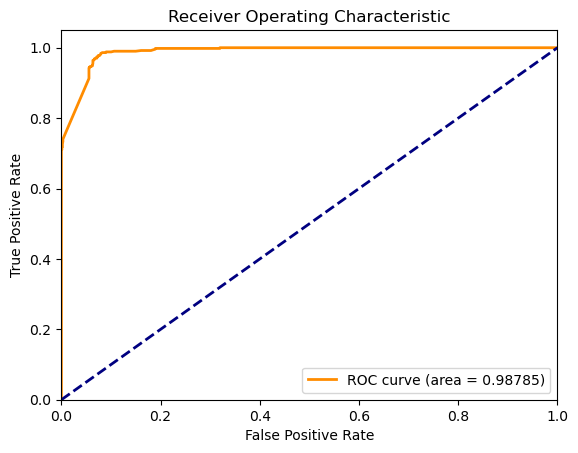

In [204]:
rf_classifier = RandomForestClassifier()
rf_classifier.fit(X_train_vec, y_train)
        
y_pred = rf_classifier.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary') 
recall = recall_score(y_test, y_pred, average='binary') 
f1 = f1_score(y_test, y_pred, average='binary')

print('Accuracy:', accuracy)
print('Confusion Matrix:\n', conf_matrix)
print('Precision:', precision)
print('Recall:', recall)
print('F1 Score:', f1)

y_pred_prob = rf_classifier.predict_proba(X_test_vec)[:, 1] 
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

new_record = {'Classifier': 'Random Forest Classifier', 'Accuracy': accuracy, 'Precision': precision, 
              'Recall': recall, 'F1 Score': f1, 'ROC curve area': roc_auc}

for key, value in new_record.items():
    metrics[key].append(value)
    
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.5f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

In [205]:
metrics

{'Classifier': ['MultinomialNB',
  'GaussianNB',
  'BernoulliNB',
  'Support Vector Machines (SVM)',
  'Logistic Regression',
  'Gradient Boosting Machines (GBM)',
  'Random Forest Classifier'],
 'Accuracy': [0.9411375661375662,
  0.908068783068783,
  0.9484126984126984,
  0.9431216931216931,
  0.9477513227513228,
  0.9259259259259259,
  0.9451058201058201],
 'Precision': [0.8893058161350844,
  0.811965811965812,
  0.8844765342960289,
  0.8813868613138686,
  0.8927911275415896,
  0.8769230769230769,
  0.8834244080145719],
 'Recall': [0.9404761904761905,
  0.9424603174603174,
  0.9722222222222222,
  0.9583333333333334,
  0.9583333333333334,
  0.9047619047619048,
  0.9623015873015873],
 'F1 Score': [0.914175506268081,
  0.8723599632690541,
  0.9262759924385633,
  0.9182509505703422,
  0.924401913875598,
  0.890625,
  0.9211775878442545],
 'ROC curve area': [0.98592116244646,
  0.9172099395313681,
  0.988981993260267,
  0.9810179280045351,
  0.989903195074326,
  0.9837815334467119,
  0.98

In [206]:
metrics_data = pd.DataFrame(metrics)

In [194]:
metrics_data

,Classifier,Accuracy,Precision,Recall,F1 Score,ROC curve area
0,MultinomialNB,0.941138,0.889306,0.940476,0.914176,0.985921
1,GaussianNB,0.908069,0.811966,0.942460,0.872360,0.917210
2,BernoulliNB,0.948413,0.884477,0.972222,0.926276,0.988982
3,Support Vector Machines (SVM),0.943122,0.881387,0.958333,0.918251,0.981018
4,Logistic Regression,0.947751,0.892791,0.958333,0.924402,0.989903
5,Gradient Boosting Machines (GBM),0.925265,0.875240,0.904762,0.889756,0.983711
6,Random Forest Classifier,0.945767,0.889299,0.956349,0.921606,0.987883


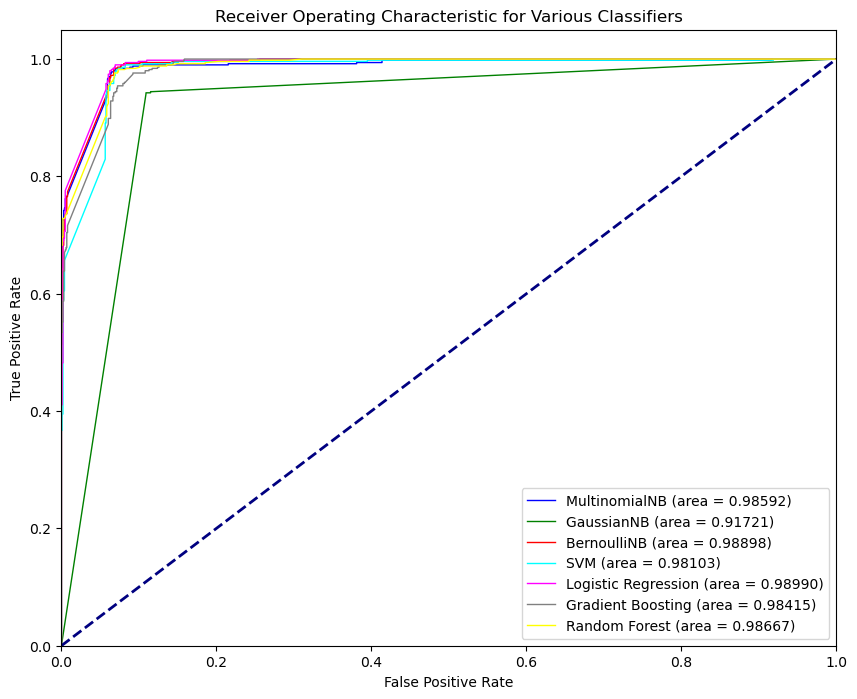

In [214]:
plt.figure(figsize=(10, 8))

classifiers = {
    'MultinomialNB': MultinomialNB(),
    'GaussianNB': GaussianNB(),
    'BernoulliNB': BernoulliNB(),
    'SVM': SVC(kernel='linear', probability=True),
    'Logistic Regression': LogisticRegression(),
    'Gradient Boosting': GradientBoostingClassifier(),
    'Random Forest': RandomForestClassifier()
}

colors = ['blue', 'green', 'red', 'cyan', 'magenta', 'gray', 'yellow']

for (label, clf), color in zip(classifiers.items(), colors):
    if label == 'GaussianNB':
        X_train_dense = X_train_vec.toarray()  # Convert to dense
        X_test_dense = X_test_vec.toarray()
        clf.fit(X_train_dense, y_train)
        y_pred_prob = clf.predict_proba(X_test_dense)[:, 1]
    else:
        clf.fit(X_train_vec, y_train)
        y_pred_prob = clf.predict_proba(X_test_vec)[:, 1]
    
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=1,
             label=f'{label} (area = {roc_auc:.5f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic for Various Classifiers')
plt.legend(loc="lower right")

plt.show()

## Discussion:
#### Comparative Analysis:
Based on the metrics, BernoulliNB shows the highest Recall (97.22%), which is crucial for spam detection as it indicates a higher ability to identify spam emails correctly. It also has a strong F1 Score (92.63%) and the second highest ROC curve area (98.90%), making it a strong candidate.

Logistic Regression and Random Forest Classifier also show impressive results with high scores across all metrics, including the highest and third-highest ROC curve areas, respectively. These classifiers are balanced in terms of Precision and Recall, which is desirable in practical applications to minimize the inconvenience of wrongly classified legitimate emails.

While GaussianNB shows high Recall, its lower Precision and Accuracy make it less ideal if reducing false positives is a priority.
#### Strengths and Weaknesses:
In the task of email spam filtering, classifiers like MultinomialNB, GaussianNB, and BernoulliNB show high Recall, which means they are good at identifying spam emails. However, GaussianNB might mark many good emails as spam because of its low Precision. BernoulliNB and MultinomialNB are fast and good for large datasets but sometimes can mark good emails as spam too. SVM and Logistic Regression are very accurate and precise but need careful tuning and can be slow with big data. Logistic Regression is also not the best for very complex patterns.

On the other hand, GBM and Random Forest perform well with complex and high-dimensional data but are resource-intensive and slower, which might not be ideal for real-time filtering. Random Forest is very robust against noise and very accurate, but it can be slow during training. Each classifier has its strengths and weaknesses, so the choice depends on the specific needs like how fast it needs to run and how critical it is to avoid marking good emails as spam. Sometimes using a combination of classifiers can help balance these factors.

#### Insights and Trade-offs:
When we choose classifiers for email spam filtering, we need to think about both how well they work and how easy they are to understand. Simple models like Naive Bayes (MultinomialNB, GaussianNB, BernoulliNB) are easy to understand and quick to run, making them good for big datasets and real-time systems. However, these models might not be very accurate in some cases and can mark good emails as spam, which is not good for users.

Complex models like SVM, Logistic Regression, GBM, and Random Forest can handle difficult patterns better and give more accurate results, but they need more computer power and time to work. These models are also harder to understand and set up correctly. If the email system needs to filter spam quickly and use less computer resources, simple models might be better. But if the goal is to catch as much spam as possible without marking good emails as spam, then more complex models could be better, even though they use more resources and are harder to understand.

In conclusion, the choice between performance and ease of understanding depends on what is more important for the email system—speed and simplicity or accuracy and detail. Sometimes, using both simple and complex models together can help balance these needs.
